# Pilot analysis: GPU agent-control crossover

## tl;dr

This notebook validates and analyzes two preregistered framework-level pilots:
a local GTX 1660 Ti run and an ephemeral Modal L4 replication. It intentionally
does **not** claim that GPU cores beat optimized CPU cores. The captured GPU
path removes Python/launch dispatch while the CPU baseline is eager PyTorch;
the next blocking experiment is a fused/compiled CPU baseline and a matched
fused GPU kernel.

Observed findings and exact caveats are generated below from the raw ledgers.

## Context & Methods

The unit is one agent-step: dense state scoring, action-state assignment,
action-specific transition lookup, and state/budget update. Initialization,
allocation, imports, and CUDA context creation are excluded. Required
synchronization is included in `wall_ms`; GPU-event time is retained as a
secondary diagnostic.

### Key assumptions

- The eight-thread eager PyTorch CPU path is a deployment baseline, not an
  optimized hardware ceiling.
- Medians summarize timing because a few CPU repetitions have scheduler/frequency
  excursions. No raw observation is deleted.
- A cell passing correctness requires exact final action agreement and the
  preregistered float tolerance. Failed cells are excluded from primary speedup
  and crossover summaries.
- Crossovers are descriptive: the smallest tested population whose median GPU
  wall time beats its matched CPU median.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter, LogLocator

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RAW_DIR = ROOT / "data/raw"
PROCESSED_DIR = ROOT / "data/processed"
FIGURE_DIR = ROOT / "results/figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

run_files = sorted(RAW_DIR.glob("pilot-00[12]-*.csv"))
assert len(run_files) >= 2, f"Expected both pilot ledgers, found {run_files}"

frames = []
manifests = {}
for csv_path in run_files:
    manifest_path = Path(str(csv_path).replace(".csv", ".manifest.json"))
    manifest = json.loads(manifest_path.read_text())
    gpu_name = manifest["cuda_devices"][0]["name"]
    run = pd.read_csv(csv_path)
    run["source_file"] = csv_path.name
    run["hardware"] = gpu_name
    run["provider"] = manifest.get("execution_provider", "local")
    frames.append(run)
    manifests[gpu_name] = manifest

raw = pd.concat(frames, ignore_index=True)
raw.shape, list(manifests)

((1960, 27), ['NVIDIA GeForce GTX 1660 Ti', 'NVIDIA L4'])

## Data

In [2]:
grain_key = ["source_file", "case_id", "repetition"]
case_key = [
    "hardware", "agent_count", "state_width", "action_count", "mode", "threads"
]

quality_rows = []
for source_file, run in raw.groupby("source_file", sort=False):
    counts = run.groupby("case_id").size()
    cell_stats = (
        run.groupby(case_key, dropna=False)["wall_ms"]
        .agg(["mean", "std", "median"])
        .reset_index()
    )
    cell_stats["cv"] = cell_stats["std"] / cell_stats["mean"]
    quality_rows.append(
        {
            "source_file": source_file,
            "rows": len(run),
            "cases": run["case_id"].nunique(),
            "min_repetitions": int(counts.min()),
            "max_repetitions": int(counts.max()),
            "duplicate_case_repetitions": int(run.duplicated(grain_key).sum()),
            "execution_errors": int((run["status"] != "ok").sum()),
            "correctness_failed_rows": int((run["correctness_valid"] != True).sum()),
            "required_metric_nulls": int(
                run[["wall_ms", "agent_steps_per_second", "ns_per_agent_step"]]
                .isna()
                .sum()
                .sum()
            ),
            "median_cell_cv": cell_stats["cv"].median(),
            "p90_cell_cv": cell_stats["cv"].quantile(0.90),
            "cells_cv_over_10pct": int((cell_stats["cv"] > 0.10).sum()),
        }
    )

quality = pd.DataFrame(quality_rows)
quality

,source_file,rows,cases,min_repetitions,max_repetitions,duplicate_case_repetitions,execution_errors,correctness_failed_rows,required_metric_nulls,median_cell_cv,p90_cell_cv,cells_cv_over_10pct
0,pilot-001-local-crossover-20260811T150801Z.csv,1400,140,10,10,0,0,50,0,0.012432,0.117143,16
1,pilot-002-modal-l4-crossover-20260811T152258Z.csv,560,80,7,7,0,0,35,0,0.017713,0.093295,8


In [3]:
failed_correctness = (
    raw.loc[
        raw["correctness_valid"] != True,
        [
            "hardware", "agent_count", "state_width", "action_count",
            "correctness_action_match", "correctness_max_abs_error",
            "correctness_max_rel_error",
        ],
    ]
    .drop_duplicates()
    .sort_values(["hardware", "agent_count", "state_width", "action_count"])
)
failed_correctness

,hardware,agent_count,state_width,action_count,correctness_action_match,correctness_max_abs_error,correctness_max_rel_error
270,NVIDIA GeForce GTX 1660 Ti,1048576,32,8,True,0.000035,0.001776
1456,NVIDIA L4,1048576,32,8,True,0.000035,0.001776


The same `(N=1,048,576, W=32, A=8)` cell exceeds the preregistered float
tolerance on both GPU architectures. Final actions agree exactly; the maximum
state difference is reported above. Because the threshold was frozen first,
the primary analysis excludes the cell rather than changing tolerance after
seeing the result.

## Results

In [4]:
summary = (
    raw.groupby(case_key, dropna=False)
    .agg(
        repetitions=("wall_ms", "size"),
        median_wall_ms=("wall_ms", "median"),
        mean_wall_ms=("wall_ms", "mean"),
        std_wall_ms=("wall_ms", "std"),
        p10_wall_ms=("wall_ms", lambda values: values.quantile(0.10)),
        p90_wall_ms=("wall_ms", lambda values: values.quantile(0.90)),
        median_ns_per_agent_step=("ns_per_agent_step", "median"),
        correctness_valid=("correctness_valid", "all"),
    )
    .reset_index()
)
summary["cv"] = summary["std_wall_ms"] / summary["mean_wall_ms"]

cpu8 = (
    summary[(summary["mode"] == "cpu") & (summary["threads"] == 8)]
    [["hardware", "agent_count", "state_width", "action_count", "median_wall_ms"]]
    .rename(columns={"median_wall_ms": "cpu8_median_wall_ms"})
)
gpu = summary[summary["mode"] != "cpu"].merge(
    cpu8,
    on=["hardware", "agent_count", "state_width", "action_count"],
    how="left",
    validate="many_to_one",
)
gpu["speedup_vs_cpu8"] = gpu["cpu8_median_wall_ms"] / gpu["median_wall_ms"]
gpu["primary_valid"] = gpu["correctness_valid"].fillna(False)

summary.to_csv(PROCESSED_DIR / "pilot-cell-summary.csv", index=False)
gpu.head()

,hardware,agent_count,state_width,action_count,mode,threads,repetitions,median_wall_ms,mean_wall_ms,std_wall_ms,p10_wall_ms,p90_wall_ms,median_ns_per_agent_step,correctness_valid,cv,cpu8_median_wall_ms,speedup_vs_cpu8,primary_valid
0,NVIDIA GeForce GTX 1660 Ti,256,8,1,eager-host-visible,NaN,10,8.411385,8.492138,0.212068,8.302451,8.762291,513.390228,True,0.024972,2.847635,0.338545,True
1,NVIDIA GeForce GTX 1660 Ti,256,8,1,eager-resident,NaN,10,7.301611,7.367101,0.341096,7.083225,7.608006,445.654999,True,0.046300,2.847635,0.390001,True
2,NVIDIA GeForce GTX 1660 Ti,256,8,1,graph-resident,NaN,10,1.182533,1.183354,0.002183,1.181757,1.186197,72.176086,True,0.001845,2.847635,2.408081,True
3,NVIDIA GeForce GTX 1660 Ti,256,8,8,eager-host-visible,NaN,10,8.637530,8.648049,0.234109,8.429153,8.865586,527.192993,True,0.027071,2.797812,0.323913,True
4,NVIDIA GeForce GTX 1660 Ti,256,8,8,eager-resident,NaN,10,6.808779,6.860341,0.084901,6.789776,6.967776,415.574890,True,0.012376,2.797812,0.410912,True


In [5]:
valid_gpu = gpu[gpu["primary_valid"]].copy()
crossovers = (
    valid_gpu[valid_gpu["speedup_vs_cpu8"] > 1]
    .groupby(["hardware", "state_width", "action_count", "mode"], as_index=False)
    .agg(crossover_n=("agent_count", "min"))
)
max_speedups = (
    valid_gpu.groupby(["hardware", "state_width", "action_count", "mode"], as_index=False)
    .agg(max_valid_speedup=("speedup_vs_cpu8", "max"))
)
crossover_table = max_speedups.merge(
    crossovers,
    on=["hardware", "state_width", "action_count", "mode"],
    how="left",
)
crossover_table.to_csv(PROCESSED_DIR / "pilot-crossovers.csv", index=False)
crossover_table.sort_values(
    ["hardware", "state_width", "action_count", "mode"]
)

,hardware,state_width,action_count,mode,max_valid_speedup,crossover_n
0,NVIDIA GeForce GTX 1660 Ti,8,1,eager-host-visible,4.623786,16384
1,NVIDIA GeForce GTX 1660 Ti,8,1,eager-resident,5.531347,16384
2,NVIDIA GeForce GTX 1660 Ti,8,1,graph-resident,5.604892,256
3,NVIDIA GeForce GTX 1660 Ti,8,8,eager-host-visible,6.046104,16384
4,NVIDIA GeForce GTX 1660 Ti,8,8,eager-resident,7.246529,16384
5,NVIDIA GeForce GTX 1660 Ti,8,8,graph-resident,7.255619,256
6,NVIDIA GeForce GTX 1660 Ti,32,1,eager-host-visible,7.000706,4096
7,NVIDIA GeForce GTX 1660 Ti,32,1,eager-resident,7.938306,4096
8,NVIDIA GeForce GTX 1660 Ti,32,1,graph-resident,7.942522,256
9,NVIDIA GeForce GTX 1660 Ti,32,8,eager-host-visible,9.518329,16384


In [6]:
MODE_STYLE = {
    "graph-resident": {"color": "#2463A8", "marker": "o", "linestyle": "-", "label": "CUDA Graph, resident"},
    "eager-resident": {"color": "#D97823", "marker": "s", "linestyle": "-", "label": "Eager GPU, resident"},
    "eager-host-visible": {"color": "#4B5563", "marker": "^", "linestyle": "--", "label": "Eager GPU, host-visible"},
}

sns.set_theme(style="whitegrid", context="paper")
figure_paths = []


def compact_population(value, _position):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.3g}M"
    if value >= 1_000:
        return f"{value / 1_000:.3g}K"
    return f"{value:g}"


def speedup_label(value, _position):
    return f"{value:g}×"


for hardware, hardware_data in gpu.groupby("hardware", sort=False):
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2), sharex=True, sharey=True)
    populations = sorted(hardware_data["agent_count"].unique())
    for row_index, state_width in enumerate([8, 32]):
        for column_index, action_count in enumerate([1, 8]):
            axis = axes[row_index, column_index]
            panel = hardware_data[
                (hardware_data["state_width"] == state_width)
                & (hardware_data["action_count"] == action_count)
            ]
            for mode, style in MODE_STYLE.items():
                series = panel[(panel["mode"] == mode) & panel["primary_valid"]].sort_values(
                    "agent_count"
                )
                axis.plot(
                    series["agent_count"],
                    series["speedup_vs_cpu8"],
                    color=style["color"],
                    marker=style["marker"],
                    linestyle=style["linestyle"],
                    linewidth=1.7,
                    markersize=4.5,
                    markerfacecolor=("white" if mode == "eager-host-visible" else style["color"]),
                    label=style["label"],
                )
            axis.axhline(1.0, color="#9CA3AF", linewidth=1.0, linestyle=":")
            axis.set_xscale("log", base=2)
            axis.set_yscale("log", base=2)
            axis.set_xticks(populations)
            axis.xaxis.set_major_formatter(FuncFormatter(compact_population))
            axis.yaxis.set_major_locator(LogLocator(base=2, numticks=8))
            axis.yaxis.set_major_formatter(FuncFormatter(speedup_label))
            axis.set_title(f"State width {state_width}; action states {action_count}")
            axis.grid(True, which="major", color="#E5E7EB", linewidth=0.7)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.suptitle(f"Agent-control wall-time speedup — {hardware}", y=0.985, fontsize=14)
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.94),
    )
    fig.supxlabel("Agent population (log₂ scale)", y=0.048)
    fig.supylabel("Speedup over 8-thread eager CPU (×, log₂)", x=0.018)
    fig.text(
        0.5,
        0.012,
        "Median synchronized wall time; failed correctness cells omitted; dotted line = matched CPU parity.",
        ha="center",
        fontsize=9,
        color="#4B5563",
    )
    fig.subplots_adjust(left=0.09, right=0.98, bottom=0.12, top=0.84, hspace=0.27, wspace=0.16)
    slug = hardware.lower().replace(" ", "-").replace("/", "-")
    png_path = FIGURE_DIR / f"{slug}-speedup.png"
    svg_path = FIGURE_DIR / f"{slug}-speedup.svg"
    fig.savefig(png_path, dpi=200, bbox_inches="tight", facecolor="#FCFCFB")
    fig.savefig(svg_path, bbox_inches="tight", facecolor="#FCFCFB")
    plt.close(fig)
    figure_paths.extend([png_path, svg_path])

figure_paths

[PosixPath('/home/remy-simpc4/Projects/gpu-agent-crossover/results/figures/nvidia-geforce-gtx-1660-ti-speedup.png'),
 PosixPath('/home/remy-simpc4/Projects/gpu-agent-crossover/results/figures/nvidia-geforce-gtx-1660-ti-speedup.svg'),
 PosixPath('/home/remy-simpc4/Projects/gpu-agent-crossover/results/figures/nvidia-l4-speedup.png'),
 PosixPath('/home/remy-simpc4/Projects/gpu-agent-crossover/results/figures/nvidia-l4-speedup.svg')]

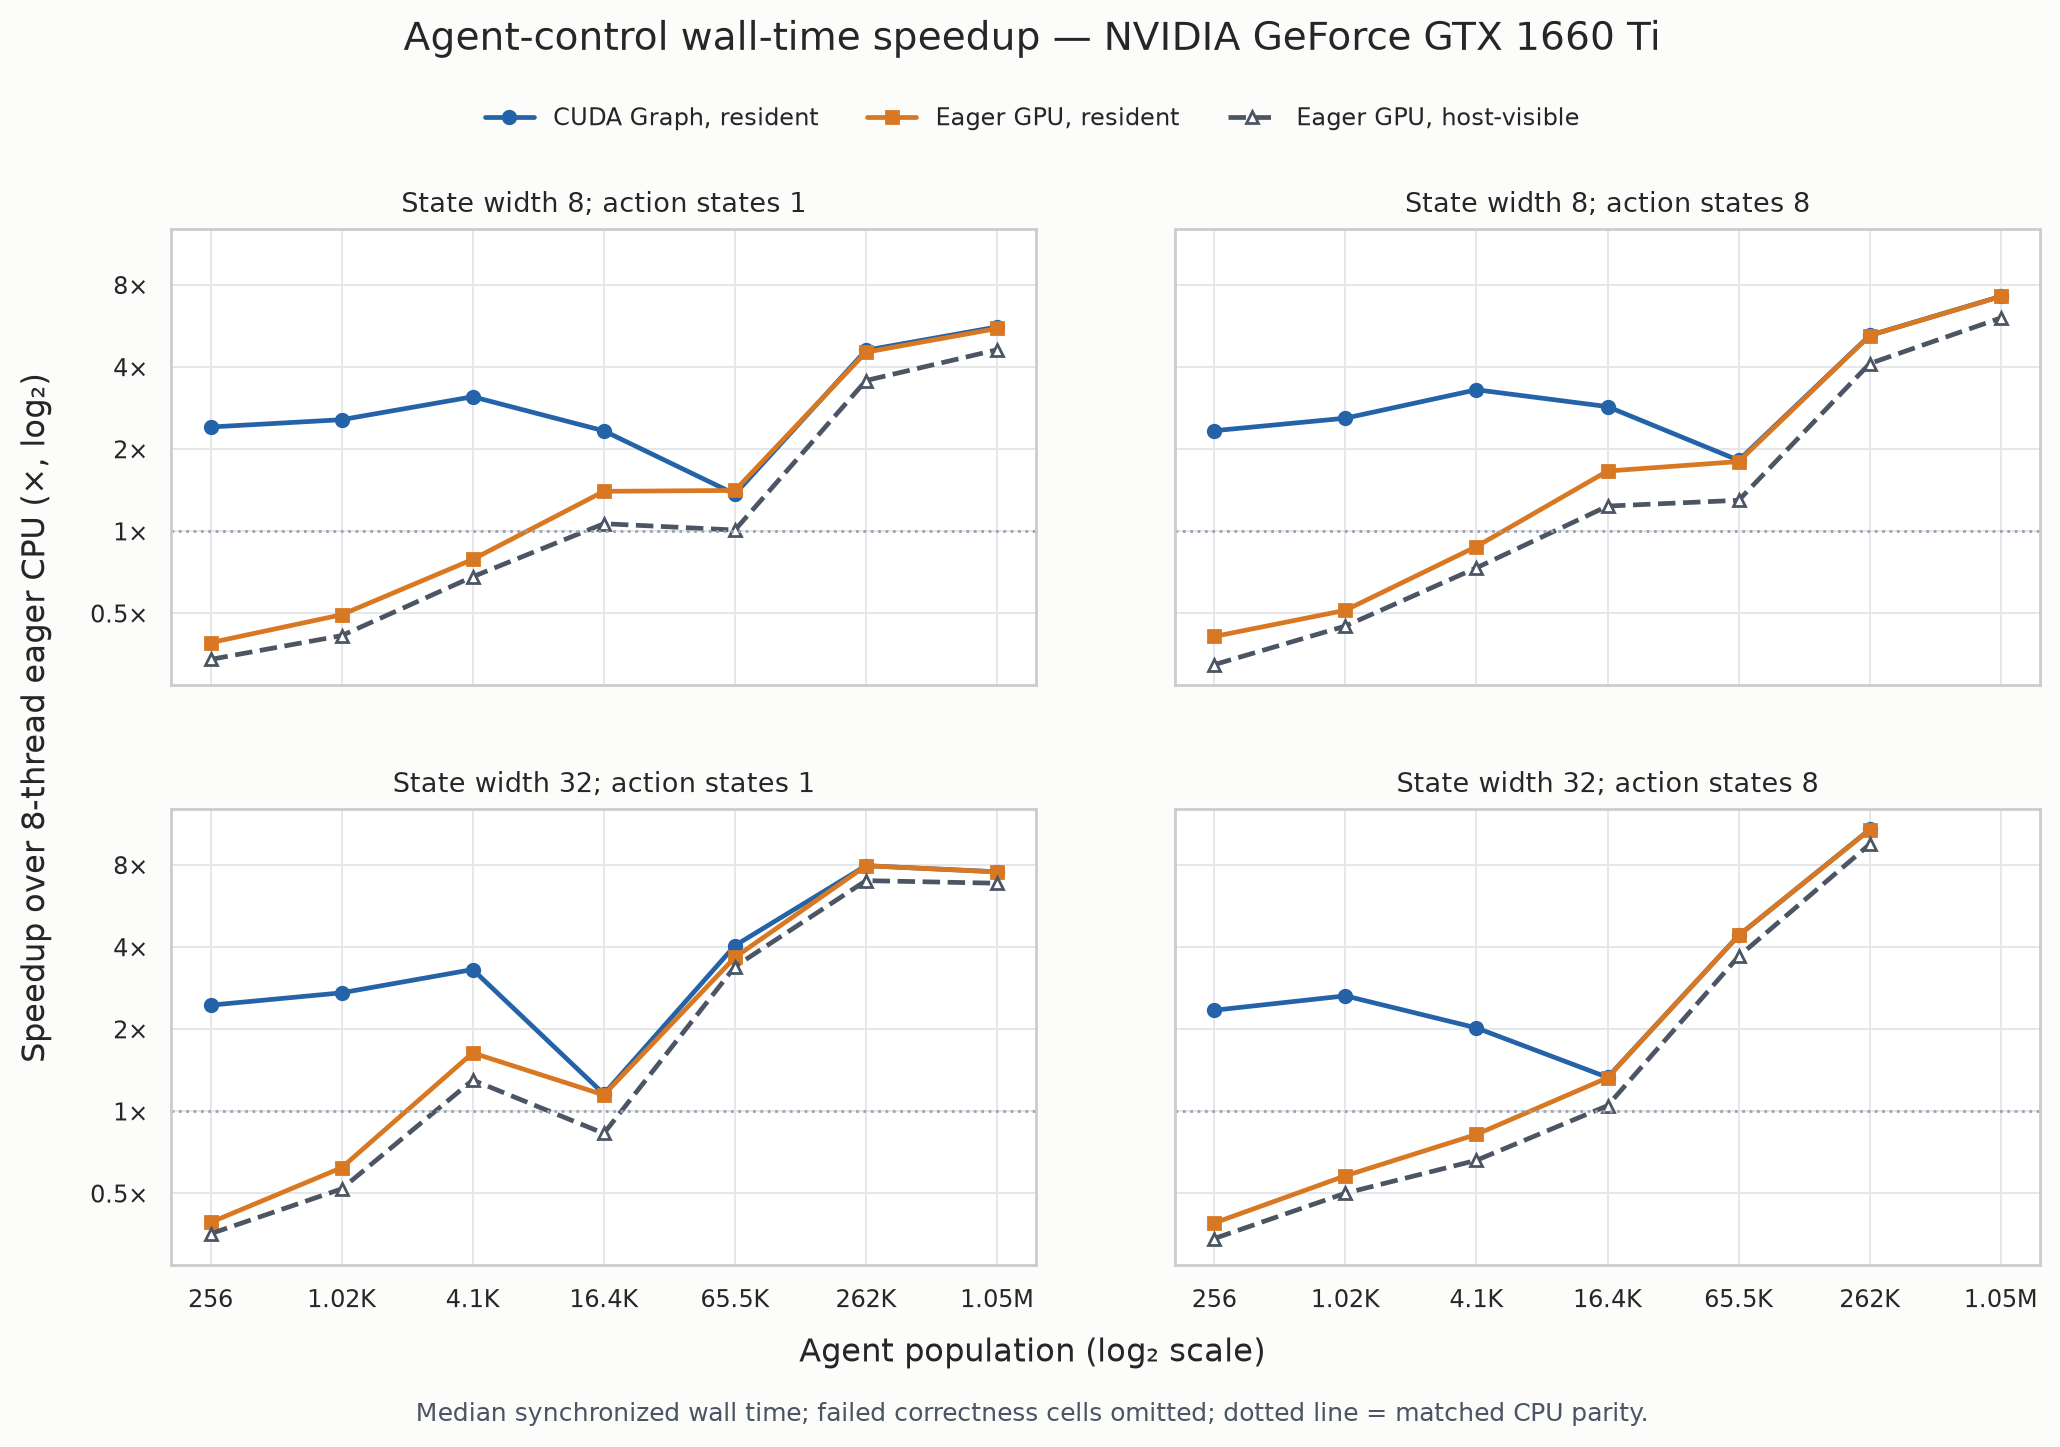

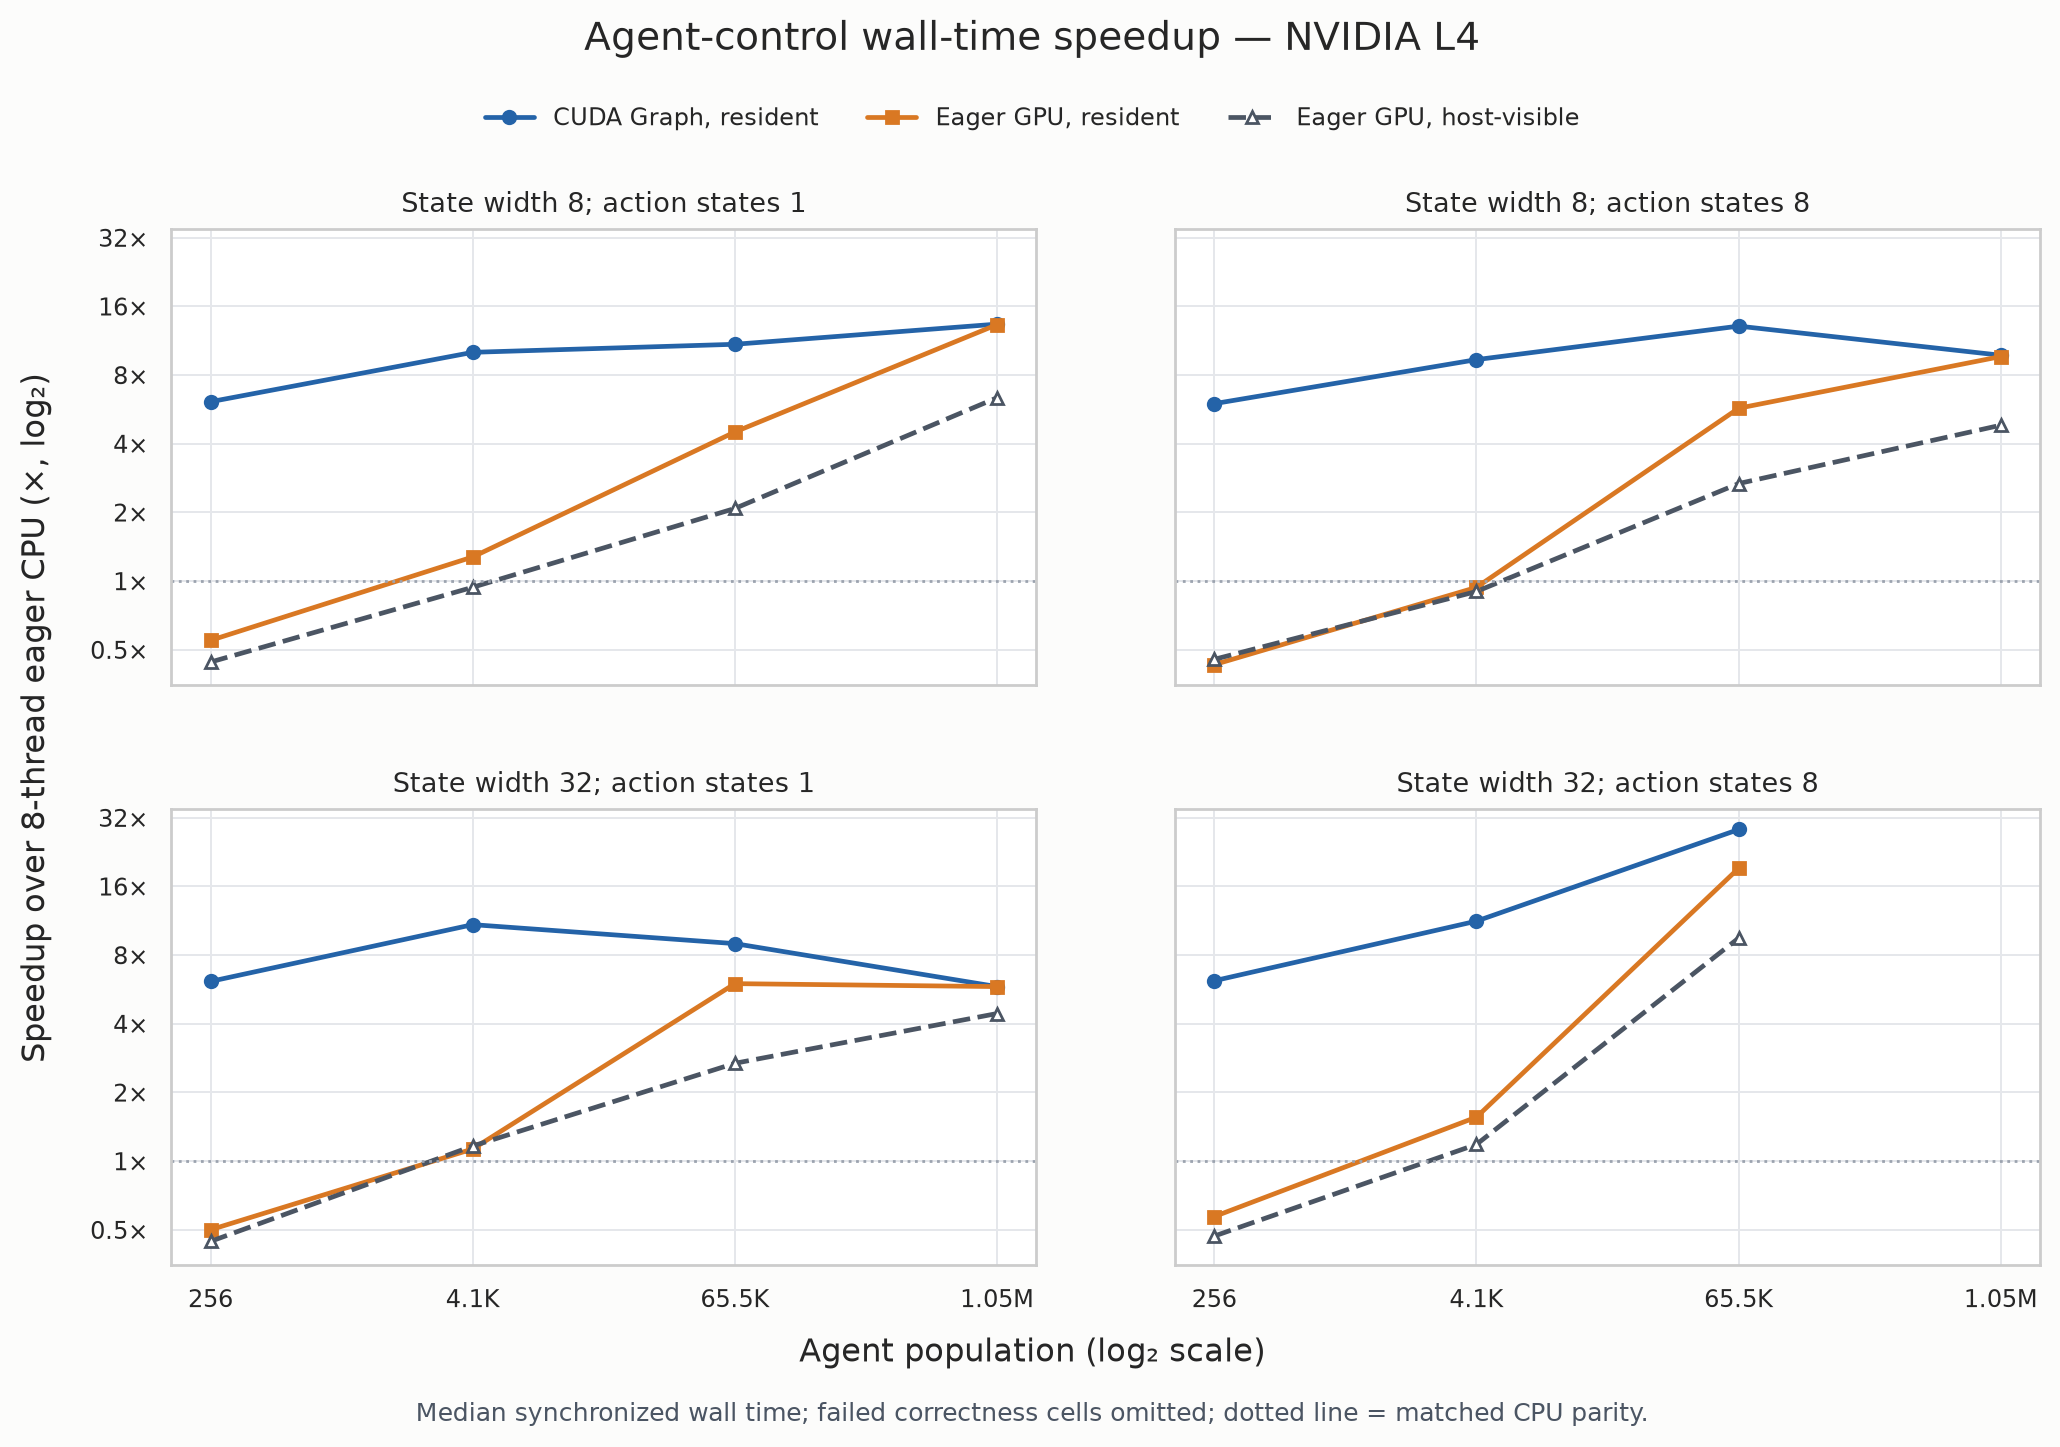

In [7]:
from IPython.display import Image, display

for figure_path in figure_paths:
    if figure_path.suffix == ".png":
        display(Image(filename=str(figure_path)))

In [8]:
gpu_raw = raw[raw["backend"] == "cuda"].copy()
gpu_raw["wall_to_event_ratio"] = gpu_raw["wall_ms"] / gpu_raw["device_ms"]
wall_event = (
    gpu_raw.groupby(["hardware", "mode"])["wall_to_event_ratio"]
    .agg(median="median", p90=lambda values: values.quantile(0.90), maximum="max")
    .reset_index()
)

high_variance = (
    summary[summary["cv"] > 0.10]
    [["hardware", "agent_count", "state_width", "action_count", "mode", "threads", "cv"]]
    .sort_values("cv", ascending=False)
)
wall_event, high_variance.head(12)

(                     hardware                mode    median       p90  \
 0  NVIDIA GeForce GTX 1660 Ti  eager-host-visible  1.002689  1.003493   
 1  NVIDIA GeForce GTX 1660 Ti      eager-resident  1.003242  1.004034   
 2  NVIDIA GeForce GTX 1660 Ti      graph-resident  1.003835  1.014003   
 3                   NVIDIA L4  eager-host-visible  1.003861  1.006439   
 4                   NVIDIA L4      eager-resident  1.006088  1.010532   
 5                   NVIDIA L4      graph-resident  1.022860  1.041361   
 
     maximum  
 0  1.006973  
 1  1.007180  
 2  1.020803  
 3  1.008554  
 4  1.039538  
 5  1.063632  ,
                        hardware  agent_count  state_width  action_count  \
 36   NVIDIA GeForce GTX 1660 Ti         1024           32             8   
 61   NVIDIA GeForce GTX 1660 Ti        16384            8             1   
 51   NVIDIA GeForce GTX 1660 Ti         4096           32             1   
 71   NVIDIA GeForce GTX 1660 Ti        16384           32            

## Takeaways

1. **The residency/dispatch hypothesis survives two hardware environments.**
   Captured resident execution crosses the eager eight-thread CPU baseline at
   the smallest tested population in every valid stratum. Eager and host-visible
   paths cross later, with the exact boundary depending on workload and host.
2. **Host visibility has a measurable tax.** Copying every action vector to the
   host raises wall time and usually moves the crossover upward. This is the
   cleanest result to carry into the next design.
3. **This is not yet a fair hardware contest.** CUDA Graph replay removes an
   entire repeated Python dispatch graph. The CPU baseline does not receive an
   equivalent fused implementation. The correct paper claim today is about the
   cost of runtime structure and residency—not GPU cores replacing CPU cores.
4. **Correctness is nearly, but not fully, clean under the frozen threshold.**
   The largest wide-state cell has exact action agreement but a maximum float
   state difference above `1e-5`; it is excluded from primary summaries.
5. **Timing stability is mixed.** Typical cells are stable, while a minority of
   multithreaded CPU cells have large excursions. A pinned/fused CPU replication
   is required before confirmatory inference.

### Next blocking experiment

Implement matched fused kernels: a compiled/Numba CPU outer-agent loop and a
single fused CUDA/Triton kernel, both with identical float semantics and
residency. Add CPU affinity/frequency telemetry, continuous power sampling, and
real agent-trace replay. Only then estimate a hardware crossover law or cloud
cost frontier.